In [1]:
# ============================================================
# Imports & Setup
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
from numpy.linalg import inv, slogdet

np.random.seed(42)

# ── Model Parameters ──────────────────────────────────────
n         = 100
beta_true = np.array([2, 1.5, -0.8])
sigma2    = 1.0

X = np.hstack([np.ones((n,1)), np.random.randn(n,2)])

# ── Heteroscedastic Sigma ──────────────────────────────────
sigma_i2  = np.linspace(0.5, 3, n)
Sigma     = np.diag(sigma_i2)
Sigma_inv = np.diag(1 / sigma_i2)

# ── Generate Data ──────────────────────────────────────────
y_homo   = X @ beta_true + np.random.normal(0, np.sqrt(sigma2), n)
y_hetero = X @ beta_true + np.array([np.random.normal(0, np.sqrt(s))
                                      for s in sigma_i2]) # each one takes different varience

print(f"  X shape    : {X.shape}")
print(f"  beta_true  : {beta_true}")
print(f"  sigma2     : {sigma2}")

  X shape    : (100, 3)
  beta_true  : [ 2.   1.5 -0.8]
  sigma2     : 1.0


In [2]:
# ============================================================
# Section 3.1.1
# ============================================================

# ── Homoscedastic ─────────────────────────────────────────
# -n/2 * log(2*pi*sigma2) - 1/(2*sigma2) * ||y - X@beta||^2
def log_likelihood_homo(beta, X, y, sigma2):
    n     = len(y)
    resid = y - X @ beta
    const = -(n/2) * np.log(2 * np.pi * sigma2)
    quad  = -(1/(2*sigma2)) * (resid @ resid)
    return const + quad

# ── Heteroscedastic ───────────────────────────────────────
# -n/2*log(2pi) - 1/2*log|Sigma| - 1/2*(y-Xb)^T Sigma^{-1} (y-Xb)
def log_likelihood_hetero(beta, X, y, Sigma, Sigma_inv):
    n         = len(y)
    resid     = y - X @ beta
    _, logdet = slogdet(Sigma)
    const     = -(n/2) * np.log(2*np.pi)
    det_term  = -0.5 * logdet
    quad      = -0.5 * (resid @ Sigma_inv @ resid)
    return const + det_term + quad

print("=" * 50)
print("3.1.1 — Log-Likelihoods at true beta")
print("=" * 50)
print(f"  Homo  : {log_likelihood_homo(beta_true, X, y_homo, sigma2):.3f}")
print(f"  Hetero: {log_likelihood_hetero(beta_true, X, y_hetero, Sigma, Sigma_inv):.3f}")

3.1.1 — Log-Likelihoods at true beta
  Homo  : -150.300
  Hetero: -153.875


In [3]:
# ============================================================
# Section 3.1.2 — OLS & WLS Estimators
# ============================================================

# ── OLS ───────────────────────────────────────────────────
# beta_hat = (X^T X)^{-1} X^T y

def OLS(X, y):
    return inv(X.T @ X) @ X.T @ y

# ── WLS ───────────────────────────────────────────────────

# => beta_hat = (X^T Sigma^{-1} X)^{-1} X^T Sigma^{-1} y
def WLS(X, y, Sigma_inv):
    return inv(X.T @ Sigma_inv @ X) @ X.T @ Sigma_inv @ y

beta_ols = OLS(X, y_homo)
beta_wls = WLS(X, y_hetero, Sigma_inv)

# Verify: log-likelihood at OLS >= at true beta (MLE property)
ll_ols       = log_likelihood_homo(beta_ols, X, y_homo, sigma2)
ll_true_homo = log_likelihood_homo(beta_true, X, y_homo, sigma2)

print("=" * 50)
print("3.1.2 — MLE Estimators")
print("=" * 50)
print(f"  True beta : {beta_true}")
print(f"  OLS       : {beta_ols.round(4)}")
print(f"  WLS       : {beta_wls.round(4)}")
print(f" {ll_ols:.3f} ≥ {ll_true_homo:.3f}  "
      f"{'✓' if ll_ols >= ll_true_homo else '✗'}")

3.1.2 — MLE Estimators
  True beta : [ 2.   1.5 -0.8]
  OLS       : [ 2.0928  1.6907 -0.9721]
  WLS       : [ 2.138   1.5742 -0.8287]
 -147.396 ≥ -150.300  ✓


In [24]:
# ============================================================
# Section 3.1.3
# ============================================================

# ── Model Assumptions ────────────────────────────────
print("=" * 50)
print("3.1.3-A — Model Assumptions")
print("=" * 50)
print("  1. y = X @ beta + epsilon       (linearity)")
print("  2. X is fixed and known         (non-random)")
print("  3. epsilon ~ N(0, sigma2*I)     (homo assumption)")
print("     OR epsilon ~ N(0, Sigma)     (hetero assumption)")

# ── 3-B: Why beta_hat is Random ───────────────────────────
# beta_hat = beta + (X^T X)^{-1} X^T epsilon

print("\n" + "=" * 50)
print("3.1.3-B — beta_hat is a Random Variable")
print("=" * 50)

for i in range(5):
    eps   = np.random.normal(0, np.sqrt(sigma2), n)
    y_new = X @ beta_true + eps
    b     = OLS(X, y_new)
    print(f"  Run {i+1}: beta_hat = {b.round(4)}")

# ── 3-C: Theoretical Distribution ─────────────────────────
# Homo OLS  : beta_hat ~ N(beta, sigma2*(X^TX)^{-1})
# Hetero WLS: beta_hat ~ N(beta, (X^T Sigma^{-1} X)^{-1})
# Misspec   : beta_hat ~ N(beta, sandwich)
print("\n" + "=" * 50)
print("3.1.3-C — Theoretical Distribution of beta_hat")
print("=" * 50)

XtX_inv        = inv(X.T @ X)
cov_ols_homo   = sigma2 * XtX_inv                         # homo OLS covariance
cov_wls        = inv(X.T @ Sigma_inv @ X)                 # hetero WLS covariance
cov_ols_hetero = XtX_inv @ (X.T @ Sigma @ X) @ XtX_inv   # sandwich (misspecified)

print(f"  OLS (homo)     Cov trace = {np.trace(cov_ols_homo):.4f}")
print(f"  WLS (hetero)   Cov trace = {np.trace(cov_wls):.4f}")
print(f"  OLS (sandwich) Cov trace = {np.trace(cov_ols_hetero):.4f}  ← inefficient")

3.1.3-A — Model Assumptions
  1. y = X @ beta + epsilon       (linearity)
  2. X is fixed and known         (non-random)
  3. epsilon ~ N(0, sigma2*I)     (homo assumption)
     OR epsilon ~ N(0, Sigma)     (hetero assumption)

3.1.3-B — beta_hat is a Random Variable
  Run 1: beta_hat = [ 1.9252  1.4593 -0.7344]
  Run 2: beta_hat = [ 2.042   1.5623 -0.8165]
  Run 3: beta_hat = [ 1.9482  1.4262 -0.8433]
  Run 4: beta_hat = [ 2.0608  1.5262 -0.6703]
  Run 5: beta_hat = [ 2.1097  1.549  -0.7826]

3.1.3-C — Theoretical Distribution of beta_hat
  OLS (homo)     Cov trace = 0.0341
  WLS (hetero)   Cov trace = 0.0473
  OLS (sandwich) Cov trace = 0.0592  ← inefficient


3.2 — OLS Single Sample
                        b0       b1       b2
  True beta         2.0000   1.5000  -0.8000
  OLS estimate      2.0451   1.5981  -0.9300
  Error             0.0451   0.0981  -0.1300

  Theoretical std : [0.101  0.1174 0.1007]
  epsilon mean    : 0.0293  (expect ≈ 0)
  epsilon std     : 0.8665   (expect ≈ 1.0000)


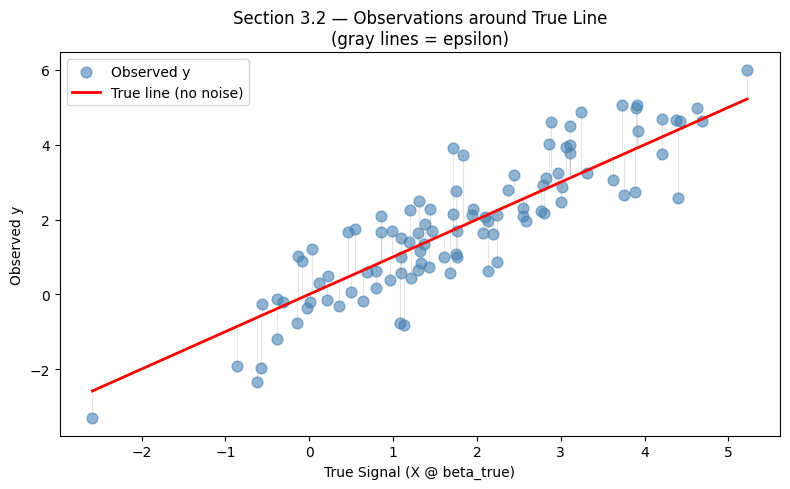

In [26]:
# ============================================================
# Section 3.2 — OLS on One Sample + Residuals around True Line
# ============================================================

# ── Generate one homoscedastic sample ─────────────────────
epsilon = np.random.normal(0, np.sqrt(sigma2), n)   # epsilon ~ N(0, sigma2*I)
y       = X @ beta_true + epsilon                    # y = X*beta + epsilon

# ── OLS estimate ──────────────────────────────────────────
beta_hat = OLS(X, y)

# ── Theoretical covariance ────────────────────────────────
# beta_hat ~ N(beta_true, sigma2 * (X^T X)^{-1})
XtX_inv  = inv(X.T @ X)
theo_cov  = sigma2 * XtX_inv
theo_mean = beta_true
theo_std  = np.sqrt(np.diag(theo_cov))

print("=" * 50)
print("3.2 — OLS Single Sample")
print("=" * 50)
print(f"  {'':15s} {'b0':>8} {'b1':>8} {'b2':>8}")
print(f"  {'True beta':15s} {beta_true[0]:>8.4f} {beta_true[1]:>8.4f} {beta_true[2]:>8.4f}")
print(f"  {'OLS estimate':15s} {beta_hat[0]:>8.4f} {beta_hat[1]:>8.4f} {beta_hat[2]:>8.4f}")
print(f"  {'Error':15s} {(beta_hat-beta_true)[0]:>8.4f} {(beta_hat-beta_true)[1]:>8.4f} {(beta_hat-beta_true)[2]:>8.4f}")
print(f"\n  Theoretical std : {theo_std.round(4)}")
print(f"  epsilon mean    : {epsilon.mean():.4f}  (expect ≈ 0)")
print(f"  epsilon std     : {epsilon.std():.4f}   (expect ≈ {np.sqrt(sigma2):.4f})")

# ── Plot: Observations around True Line ───────────────────
y_hat_true = X @ beta_true

fig, ax = plt.subplots(figsize=(8, 5))

#observed
ax.scatter(y_hat_true, y,
           color='steelblue', alpha=0.6, s=60,
           label='Observed y')

# true line
ax.plot([y_hat_true.min(), y_hat_true.max()],
        [y_hat_true.min(), y_hat_true.max()],
        'r-', linewidth=2, label='True line (no noise)')

for i in range(len(y)):
    ax.plot([y_hat_true[i], y_hat_true[i]],
            [y_hat_true[i], y[i]],
            'gray', alpha=0.2, linewidth=0.8)

ax.set_xlabel('True Signal (X @ beta_true)')
ax.set_ylabel('Observed y')
ax.set_title('Section 3.2 — Observations around True Line\n(gray lines = epsilon)')
ax.legend()
plt.tight_layout()
plt.show()

In [6]:
# ============================================================
# Section 3.2 — Monte Carlo Simulation
# ============================================================

N_sim        = 5000
beta_hat_all = np.zeros((N_sim, len(beta_true)))   # shape: (5000, 3)

for i in range(N_sim):
    eps_i = np.random.normal(0, np.sqrt(sigma2), n)  # different epsilon for each i
    y_i = X @ beta_true + eps_i                      # new y depending on the i and the eps
    beta_hat_all[i] = OLS(X, y_i)

# ── Empirical Statistics ───────────────────────────────────
emp_mean = beta_hat_all.mean(axis=0)    # average of each each component for the 5000 run <must be beta true as it is not biased>
emp_cov  = np.cov(beta_hat_all.T)       # to be a column
emp_std  = beta_hat_all.std(axis=0)

print("=" * 55)
print("3.2 — Monte Carlo Results  (N_sim = 5000)")
print("=" * 55)
print(f"  {'':20s} {'b0':>10} {'b1':>10} {'b2':>10}")
print(f"  {'True beta':20s} {beta_true[0]:>10.4f} {beta_true[1]:>10.4f} {beta_true[2]:>10.4f}")
print(f"  {'Empirical Mean':20s} {emp_mean[0]:>10.4f} {emp_mean[1]:>10.4f} {emp_mean[2]:>10.4f}")
print(f"  {'Theoretical Mean':20s} {beta_true[0]:>10.4f} {beta_true[1]:>10.4f} {beta_true[2]:>10.4f}")
print(f"  {'Empirical Std':20s} {emp_std[0]:>10.4f} {emp_std[1]:>10.4f} {emp_std[2]:>10.4f}")
print(f"  {'Theoretical Std':20s} {theo_std[0]:>10.4f} {theo_std[1]:>10.4f} {theo_std[2]:>10.4f}")
print(f"\n  Empirical Covariance:\n  {emp_cov.round(4)}")
print(f"\n  Theoretical Covariance:\n  {theo_cov.round(4)}")

# the estimator is unbiased as the emp mean very close to the mean, the theoritical and empirical covs have closed coefficients

3.2 — Monte Carlo Results  (N_sim = 5000)
                               b0         b1         b2
  True beta                2.0000     1.5000    -0.8000
  Empirical Mean           1.9988     1.5000    -0.8038
  Theoretical Mean         2.0000     1.5000    -0.8000
  Empirical Std            0.1026     0.1148     0.0999
  Theoretical Std          0.1010     0.1174     0.1007

  Empirical Covariance:
  [[ 0.0105  0.0014 -0.0003]
 [ 0.0014  0.0132 -0.0003]
 [-0.0003 -0.0003  0.01  ]]

  Theoretical Covariance:
  [[ 0.0102  0.0016 -0.0004]
 [ 0.0016  0.0138 -0.0004]
 [-0.0004 -0.0004  0.0101]]


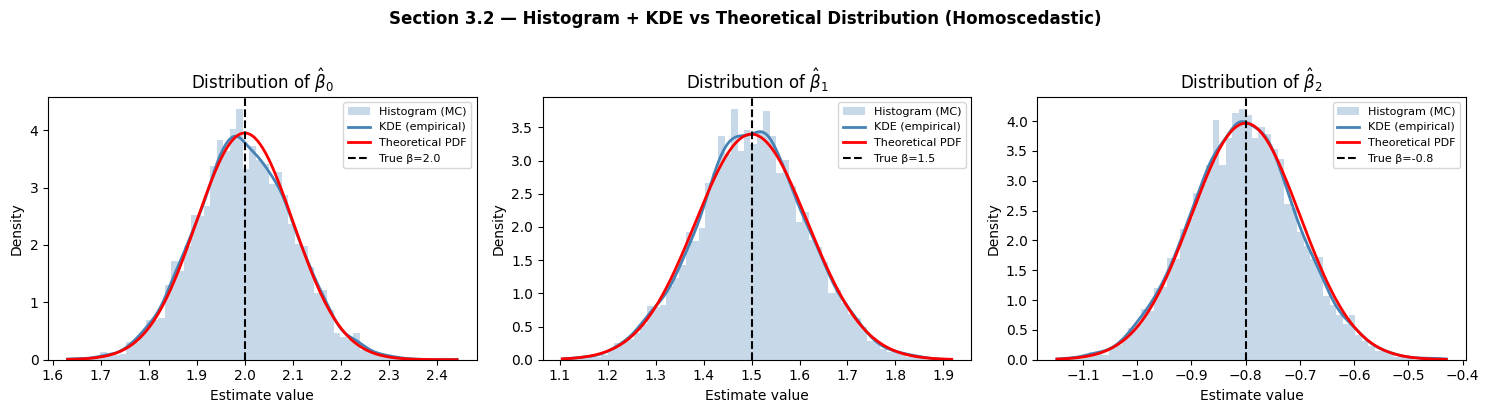

In [7]:
# ============================================================
# Section 3.2 — Histogram + KDE + Theoretical PDF
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
labels = [r'$\hat{\beta}_0$', r'$\hat{\beta}_1$', r'$\hat{\beta}_2$']

for j, ax in enumerate(axes):
    samples = beta_hat_all[:, j]

    # ── Histogram ─────────────────────────────────────────
    ax.hist(samples, bins=60, density=True,
            alpha=0.3, color='steelblue', label='Histogram (MC)')

    # ── KDE ───────────────────────────────────────────────
    kde       = stats.gaussian_kde(samples)
    x_range   = np.linspace(samples.min(), samples.max(), 300)
    ax.plot(x_range, kde(x_range),
            'steelblue', linewidth=2, label='KDE (empirical)')

    # ── Theoretical PDF ───────────────────────────────────
    pdf = stats.norm.pdf(x_range, loc=theo_mean[j], scale=theo_std[j])
    ax.plot(x_range, pdf, 'r-', linewidth=2, label='Theoretical PDF')

    # ── True Value ────────────────────────────────────────
    ax.axvline(beta_true[j], color='black', linestyle='--',
               linewidth=1.5, label=f'True β={beta_true[j]}')

    ax.set_title(f'Distribution of {labels[j]}')
    ax.set_xlabel('Estimate value')
    ax.set_ylabel('Density')
    ax.legend(fontsize=8)

plt.suptitle('Section 3.2 — Histogram + KDE vs Theoretical Distribution (Homoscedastic)',
             fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [8]:
# ================================================================================================
# Section 3.3 — Monte Carlo under Heteroscedastic Noise "see the difference between OLS ANS WLS"
# ================================================================================================

N_sim         = 5000
ols_estimates = np.zeros((N_sim, len(beta_true)))
wls_estimates = np.zeros((N_sim, len(beta_true)))

for i in range(N_sim):
    eps_i = np.array([np.random.normal(0, np.sqrt(s)) for s in sigma_i2])
    y_i   = X @ beta_true + eps_i       # y = X*beta + epsilon

    ols_estimates[i] = OLS(X, y_i)
    wls_estimates[i] = WLS(X, y_i, Sigma_inv)

# ── Empirical Statistics ───────────────────────────────────
ols_mean = ols_estimates.mean(axis=0)
wls_mean = wls_estimates.mean(axis=0)
ols_std  = ols_estimates.std(axis=0)
wls_std  = wls_estimates.std(axis=0)
ols_cov  = np.cov(ols_estimates.T)
wls_cov  = np.cov(wls_estimates.T)

# ── Theoretical Covariances ────────────────────────────────
theo_cov_ols_hetero = XtX_inv @ (X.T @ Sigma @ X) @ XtX_inv
theo_std_ols_hetero = np.sqrt(np.diag(theo_cov_ols_hetero))

theo_cov_wls        = inv(X.T @ Sigma_inv @ X)
theo_std_wls        = np.sqrt(np.diag(theo_cov_wls))

print("=" * 60)
print("3.3 — Monte Carlo Results (Heteroscedastic, N_sim=5000)")
print("=" * 60)
print(f"\n  {'':22s} {'b0':>10} {'b1':>10} {'b2':>10}")
print(f"  {'True beta':22s} {beta_true[0]:>10.4f} {beta_true[1]:>10.4f} {beta_true[2]:>10.4f}")

print(f"\n  ── OLS (misspecified) ──")
print(f"  {'Empirical Mean':22s} {ols_mean[0]:>10.4f} {ols_mean[1]:>10.4f} {ols_mean[2]:>10.4f}")
print(f"  {'Empirical Std':22s} {ols_std[0]:>10.4f} {ols_std[1]:>10.4f} {ols_std[2]:>10.4f}")
print(f"  {'Theoretical Std':22s} {theo_std_ols_hetero[0]:>10.4f} {theo_std_ols_hetero[1]:>10.4f} {theo_std_ols_hetero[2]:>10.4f}")

print(f"\n  ── WLS (correct model) ──")
print(f"  {'Empirical Mean':22s} {wls_mean[0]:>10.4f} {wls_mean[1]:>10.4f} {wls_mean[2]:>10.4f}")
print(f"  {'Empirical Std':22s} {wls_std[0]:>10.4f} {wls_std[1]:>10.4f} {wls_std[2]:>10.4f}")
print(f"  {'Theoretical Std':22s} {theo_std_wls[0]:>10.4f} {theo_std_wls[1]:>10.4f} {theo_std_wls[2]:>10.4f}")

print(f"\n  ── Efficiency Comparison (Cov trace) ──")
print(f"  OLS sandwich trace : {np.trace(theo_cov_ols_hetero):.4f}  ← bigger = less efficient")
print(f"  WLS trace          : {np.trace(theo_cov_wls):.4f}  ← smaller = more efficient")

3.3 — Monte Carlo Results (Heteroscedastic, N_sim=5000)

                                 b0         b1         b2
  True beta                  2.0000     1.5000    -0.8000

  ── OLS (misspecified) ──
  Empirical Mean             1.9978     1.5010    -0.8031
  Empirical Std              0.1340     0.1540     0.1344
  Theoretical Std            0.1335     0.1531     0.1338

  ── WLS (correct model) ──
  Empirical Mean             1.9980     1.4996    -0.8038
  Empirical Std              0.1178     0.1372     0.1199
  Theoretical Std            0.1188     0.1374     0.1195

  ── Efficiency Comparison (Cov trace) ──
  OLS sandwich trace : 0.0592  ← bigger = less efficient
  WLS trace          : 0.0473  ← smaller = more efficient


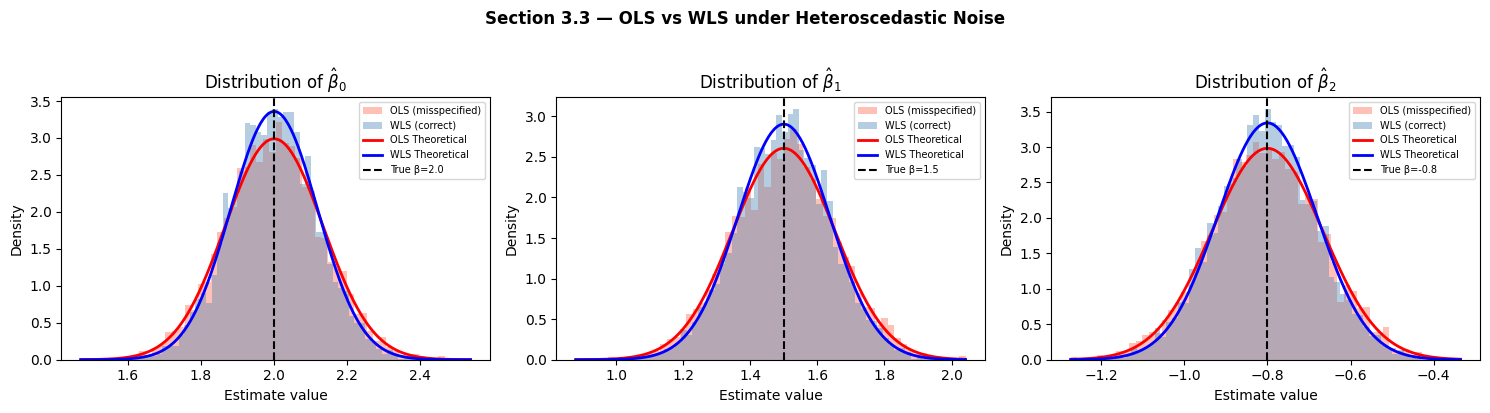

In [9]:
# ============================================================
# Section 3.3 — Plot: OLS vs WLS Distribution
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
labels = [r'$\hat{\beta}_0$', r'$\hat{\beta}_1$', r'$\hat{\beta}_2$']

for j, ax in enumerate(axes):
    ols_s = ols_estimates[:, j]
    wls_s = wls_estimates[:, j]

    # ── Histograms ────────────────────────────────────────
    ax.hist(ols_s, bins=60, density=True,
            alpha=0.4, color='tomato', label='OLS (misspecified)')
    ax.hist(wls_s, bins=60, density=True,
            alpha=0.4, color='steelblue', label='WLS (correct)')

    # ── Theoretical PDFs ──────────────────────────────────
    x_min = min(ols_s.min(), wls_s.min())
    x_max = max(ols_s.max(), wls_s.max())
    x_range = np.linspace(x_min, x_max, 300)

    # OLS PDF — wider (less efficient)
    pdf_ols = stats.norm.pdf(x_range,
                             loc=beta_true[j],
                             scale=theo_std_ols_hetero[j])
    ax.plot(x_range, pdf_ols, 'r-', linewidth=2, label='OLS Theoretical')

    # WLS PDF — narrower (more efficient)
    pdf_wls = stats.norm.pdf(x_range,
                             loc=beta_true[j],
                             scale=theo_std_wls[j])
    ax.plot(x_range, pdf_wls, 'b-', linewidth=2, label='WLS Theoretical')

    # ── True Value ────────────────────────────────────────
    ax.axvline(beta_true[j], color='black', linestyle='--',
               linewidth=1.5, label=f'True β={beta_true[j]}')

    ax.set_title(f'Distribution of {labels[j]}')
    ax.set_xlabel('Estimate value')
    ax.set_ylabel('Density')
    ax.legend(fontsize=7)

plt.suptitle('Section 3.3 — OLS vs WLS under Heteroscedastic Noise',
             fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [10]:
# ============================================================
# Section 3.3 — Efficiency Summary Table
# ============================================================

print("=" * 60)
print("3.3 — OLS vs WLS Efficiency Summary")
print("=" * 60)

print(f"\n  {'Metric':30s} {'OLS':>12} {'WLS':>12}")
print(f"  {'-'*54}")

for j in range(3):
    print(f"  {'Std of b'+str(j)+' (empirical)':30s} "
          f"{ols_std[j]:>12.4f} {wls_std[j]:>12.4f}")

print(f"  {'-'*54}")
print(f"  {'Cov Trace (theoretical)':30s} "
      f"{np.trace(theo_cov_ols_hetero):>12.4f} "
      f"{np.trace(theo_cov_wls):>12.4f}")

efficiency_gain = np.trace(theo_cov_ols_hetero) / np.trace(theo_cov_wls)
print(f"\n  Efficiency gain of WLS over OLS : {efficiency_gain:.2f}x")
print(f"\n  Conclusion:")
print(f"  - Both OLS and WLS are unbiased under heteroscedastic noise")
print(f"  - WLS has {efficiency_gain:.2f}x smaller total variance than OLS")
print(f"  - OLS ignores Sigma => wastes information => inefficient")
print(f"  - WLS uses Sigma^(-1) as weights => optimal => efficient")

3.3 — OLS vs WLS Efficiency Summary

  Metric                                  OLS          WLS
  ------------------------------------------------------
  Std of b0 (empirical)                0.1340       0.1178
  Std of b1 (empirical)                0.1540       0.1372
  Std of b2 (empirical)                0.1344       0.1199
  ------------------------------------------------------
  Cov Trace (theoretical)              0.0592       0.0473

  Efficiency gain of WLS over OLS : 1.25x

  Conclusion:
  - Both OLS and WLS are unbiased under heteroscedastic noise
  - WLS has 1.25x smaller total variance than OLS
  - OLS ignores Sigma => wastes information => inefficient
  - WLS uses Sigma^(-1) as weights => optimal => efficient


In [11]:
# ============================================================
# Section 3.4 — Confidence Intervals for beta_hat
# ============================================================

z_95 = 1.96

ci_lower = beta_hat - z_95 * theo_std
ci_upper = beta_hat + z_95 * theo_std

print("=" * 65)
print("3.4 — 95% Confidence Intervals for beta_hat")
print("=" * 65)
print(f"  {'':12s} {'Estimate':>10} {'Lower':>10} {'Upper':>10} {'True beta':>10} {'Inside?':>8}")
print(f"  {'-'*60}")

for j in range(3):
    inside = ci_lower[j] <= beta_true[j] <= ci_upper[j]
    print(f"  {'beta_'+str(j):12s} "
          f"{beta_hat[j]:>10.4f} "
          f"{ci_lower[j]:>10.4f} "
          f"{ci_upper[j]:>10.4f} "
          f"{beta_true[j]:>10.4f} "
          f"{'✓' if inside else '✗':>8}")

N_check  = 1000
covered  = np.zeros(len(beta_true))

for _ in range(N_check):
    eps_c   = np.random.normal(0, np.sqrt(sigma2), n)
    y_c     = X @ beta_true + eps_c
    b_c     = OLS(X, y_c)
    lo      = b_c - z_95 * theo_std
    hi      = b_c + z_95 * theo_std
    covered += (lo <= beta_true) & (beta_true <= hi)

coverage = covered / N_check * 100

print(f"\n  Coverage Verification (over {N_check} samples):")
print(f"  {'':12s} {'Coverage':>10} {'Expected':>10}")
print(f"  {'-'*35}")
for j in range(3):
    print(f"  {'beta_'+str(j):12s} {coverage[j]:>9.1f}%  {'95.0%':>10}")

3.4 — 95% Confidence Intervals for beta_hat
                 Estimate      Lower      Upper  True beta  Inside?
  ------------------------------------------------------------
  beta_0           2.0174     1.8195     2.2154     2.0000        ✓
  beta_1           1.3935     1.1633     1.6237     1.5000        ✓
  beta_2          -0.8554    -1.0528    -0.6581    -0.8000        ✓

  Coverage Verification (over 1000 samples):
                 Coverage   Expected
  -----------------------------------
  beta_0            94.6%       95.0%
  beta_1            94.6%       95.0%
  beta_2            94.2%       95.0%


In [12]:
# ============================================================
# Section 3.4 — Prediction Intervals for new y
# ============================================================
x_new   = np.array([1.0, 0.5, -0.3])    # [intercept, feature1, feature2]

y_hat_new = x_new @ beta_hat

var_beta_part = sigma2 * (x_new @ XtX_inv @ x_new)
var_noise     = sigma2
var_pred      = var_beta_part + var_noise
std_pred      = np.sqrt(var_pred)

var_ci  = var_beta_part
std_ci  = np.sqrt(var_ci)

# ── Intervals ──────────────────────────────────────────
pi_lower = y_hat_new - z_95 * std_pred
pi_upper = y_hat_new + z_95 * std_pred

ci_y_lower = y_hat_new - z_95 * std_ci
ci_y_upper = y_hat_new + z_95 * std_ci

y_true_new = x_new @ beta_true

print("=" * 60)
print("3.4 — Prediction vs Confidence Interval")
print("=" * 60)
print(f"\n  x_new            : {x_new}")
print(f"  y_hat (predicted): {y_hat_new:.4f}")
print(f"  y_true (no noise): {y_true_new:.4f}")

print(f"\n  {'':25s} {'Lower':>8} {'Upper':>8} {'Width':>8}")
print(f"  {'-'*52}")
print(f"  {'95% CI (mean)':25s} {ci_y_lower:>8.4f} {ci_y_upper:>8.4f} {ci_y_upper-ci_y_lower:>8.4f}")
print(f"  {'95% PI (new obs)':25s} {pi_lower:>8.4f} {pi_upper:>8.4f} {pi_upper-pi_lower:>8.4f}")

print(f"\n  Variance Breakdown:")
print(f"  beta uncertainty : {var_beta_part:.4f}")
print(f"  new noise        : {var_noise:.4f}")
print(f"  total (PI)       : {var_pred:.4f}")
print(f"\n  => PI is wider than CI by factor: {std_pred/std_ci:.2f}x")

3.4 — Prediction vs Confidence Interval

  x_new            : [ 1.   0.5 -0.3]
  y_hat (predicted): 2.9708
  y_true (no noise): 2.9900

                               Lower    Upper    Width
  ----------------------------------------------------
  95% CI (mean)               2.7189   3.2227   0.5037
  95% PI (new obs)            0.9947   4.9469   3.9522

  Variance Breakdown:
  beta uncertainty : 0.0165
  new noise        : 1.0000
  total (PI)       : 1.0165

  => PI is wider than CI by factor: 7.85x


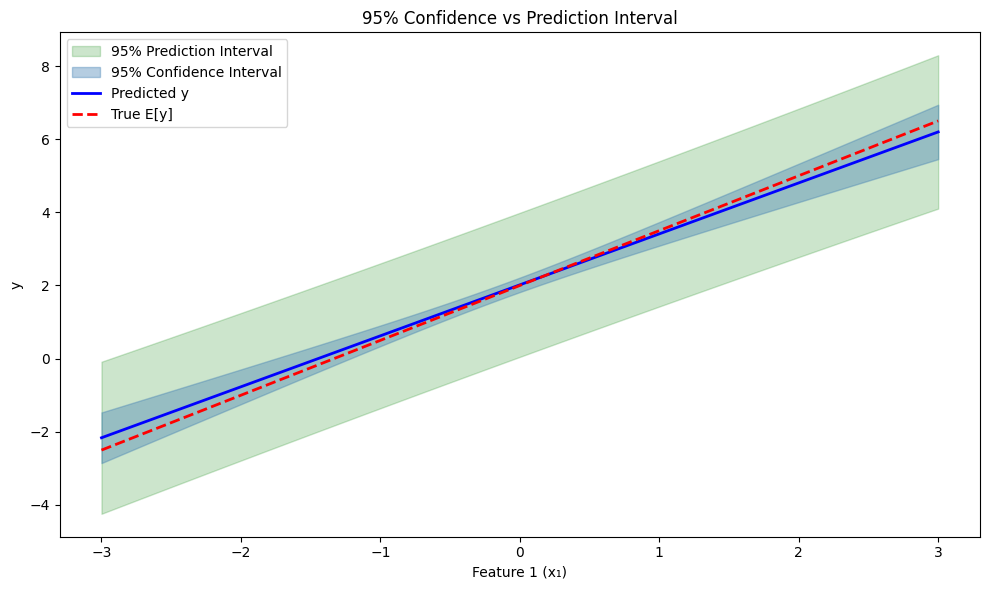

In [13]:
# ============================================================
# Section 3.4
# ============================================================
x1_range  = np.linspace(-3, 3, 100)
y_hats    = []
ci_lowers, ci_uppers = [], []
pi_lowers, pi_uppers = [], []

for x1 in x1_range:
    xn        = np.array([1.0, x1, 0.0])
    y_h       = xn @ beta_hat

    var_c     = sigma2 * (xn @ XtX_inv @ xn)
    var_p     = sigma2 * (1 + xn @ XtX_inv @ xn)

    y_hats.append(y_h)
    ci_lowers.append(y_h - z_95 * np.sqrt(var_c))
    ci_uppers.append(y_h + z_95 * np.sqrt(var_c))
    pi_lowers.append(y_h - z_95 * np.sqrt(var_p))
    pi_uppers.append(y_h + z_95 * np.sqrt(var_p))

y_hats    = np.array(y_hats)
ci_lowers = np.array(ci_lowers)
ci_uppers = np.array(ci_uppers)
pi_lowers = np.array(pi_lowers)
pi_uppers = np.array(pi_uppers)

# ── Plot ──────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 6))

# Prediction Interval
ax.fill_between(x1_range, pi_lowers, pi_uppers,
                alpha=0.2, color='green', label='95% Prediction Interval')

# Confidence Interval
ax.fill_between(x1_range, ci_lowers, ci_uppers,
                alpha=0.4, color='steelblue', label='95% Confidence Interval')

# Predicted line
ax.plot(x1_range, y_hats, 'b-', linewidth=2, label='Predicted y')

# True line
y_true_range = np.array([np.array([1.0, x1, 0.0]) @ beta_true for x1 in x1_range])
ax.plot(x1_range, y_true_range, 'r--', linewidth=2, label='True E[y]')

ax.set_xlabel('Feature 1 (x₁)')
ax.set_ylabel('y')
ax.set_title('95% Confidence vs Prediction Interval')
ax.legend()
plt.tight_layout()
plt.show()

In [14]:
# ============================================================
# Section 3.5 — Real Data Application
# ============================================================
import statsmodels.api as sm

# ── Dataset ──────────────────────────────────────
# Longley dataset: labor economics data
data    = sm.datasets.longley.load_pandas().data
print("=" * 50)
print("3.5 — Dataset Overview")
print("=" * 50)
print(f"\n  Shape : {data.shape}")
print(f"\n  Columns:\n  {list(data.columns)}")
print(data.head())
print(f"\n  Basic Statistics:")
print(data.describe().round(2))

3.5 — Dataset Overview

  Shape : (16, 7)

  Columns:
  ['TOTEMP', 'GNPDEFL', 'GNP', 'UNEMP', 'ARMED', 'POP', 'YEAR']
    TOTEMP  GNPDEFL       GNP   UNEMP   ARMED       POP    YEAR
0  60323.0     83.0  234289.0  2356.0  1590.0  107608.0  1947.0
1  61122.0     88.5  259426.0  2325.0  1456.0  108632.0  1948.0
2  60171.0     88.2  258054.0  3682.0  1616.0  109773.0  1949.0
3  61187.0     89.5  284599.0  3351.0  1650.0  110929.0  1950.0
4  63221.0     96.2  328975.0  2099.0  3099.0  112075.0  1951.0

  Basic Statistics:
         TOTEMP  GNPDEFL        GNP    UNEMP    ARMED       POP     YEAR
count     16.00    16.00      16.00    16.00    16.00      16.0    16.00
mean   65317.00   101.68  387698.44  3193.31  2606.69  117424.0  1954.50
std     3511.97    10.79   99394.94   934.46   695.92    6956.1     4.76
min    60171.00    83.00  234289.00  1870.00  1456.00  107608.0  1947.00
25%    62712.50    94.52  317881.00  2348.25  2298.00  111788.5  1950.75
50%    65504.00   100.60  381427.00  31

In [15]:
# ============================================================
# Section 3.5 — Prepare Data and Fit OLS
# ============================================================

# ──  response variable ──────────────────────────────────
y_real = data['TOTEMP'].values.astype(float)

# ──  features ───────────────────────────────────────────

X_raw_real = data[['GNP', 'UNEMP', 'POP']].values.astype(float)

# ── Design Matrix (intercept) ──────────────────────────
X_real = np.hstack([np.ones((len(y_real), 1)), X_raw_real])

print("=" * 50)
print("3.5 — Data Preparation")
print("=" * 50)
print(f"  y (TOTEMP) shape : {y_real.shape}")
print(f"  X shape          : {X_real.shape}")
print(f"  Features         : intercept, GNP, UNEMP, POP")

# ── OLS ───────────────────────────────────────────────────
def OLS(X, y):
    return inv(X.T @ X) @ X.T @ y

beta_ols_real = OLS(X_real, y_real)

print(f"\n  OLS Coefficients:")
names = ['intercept', 'GNP', 'UNEMP', 'POP']
for name, coef in zip(names, beta_ols_real):
    print(f"  {name:12s} : {coef:.4f}")

# ── Residuals ─────────────────────────────────────────────
y_hat_real  = X_real @ beta_ols_real     # predicted values
resid_real  = y_real - y_hat_real        # residuals = y - y_hat

# ── R² ────────────────────────────────────────────────────
ss_res = resid_real @ resid_real                          # sum of squared residuals
ss_tot = ((y_real - y_real.mean())**2).sum()             # total sum of squares
r2     = 1 - ss_res / ss_tot                             # R²

print(f"\n  R² = {r2:.4f}  ({'good fit' if r2 > 0.9 else 'moderate fit'})")

3.5 — Data Preparation
  y (TOTEMP) shape : (16,)
  X shape          : (16, 4)
  Features         : intercept, GNP, UNEMP, POP

  OLS Coefficients:
  intercept    : 66157.7473
  GNP          : 0.0476
  UNEMP        : -0.3854
  POP          : -0.1539

  R² = 0.9812  (good fit)


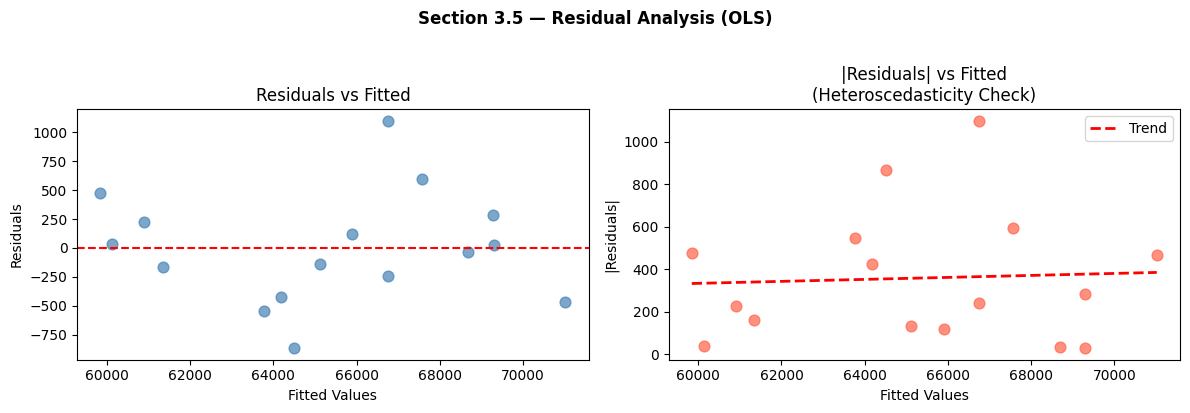

  p-value      : 0.7550
  => p > 0.05: No strong evidence → OLS ok


In [32]:
# ============================================================
# Section 3.5 — Residual Analysis
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# ── Plot 1: Residuals vs Fitted ────────────────────────────
axes[0].scatter(y_hat_real, resid_real,
                color='steelblue', alpha=0.7, s=60)
axes[0].axhline(0, color='red', linestyle='--', linewidth=1.5)
axes[0].set_xlabel('Fitted Values')
axes[0].set_ylabel('Residuals')
axes[0].set_title('Residuals vs Fitted')

# ── Plot 2: |Residuals| vs Fitted ─────────────────────────
axes[1].scatter(y_hat_real, np.abs(resid_real),
                color='tomato', alpha=0.7, s=60)
axes[1].set_xlabel('Fitted Values')
axes[1].set_ylabel('|Residuals|')
axes[1].set_title('|Residuals| vs Fitted\n(Heteroscedasticity Check)')

z = np.polyfit(y_hat_real, np.abs(resid_real), 1)
p = np.poly1d(z)
axes[1].plot(np.sort(y_hat_real), p(np.sort(y_hat_real)),
             'r--', linewidth=2, label='Trend')
axes[1].legend()

plt.suptitle('Section 3.5 — Residual Analysis (OLS)',
             fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# ── Breusch-Pagan Test ─────────────────────────────────────
resid2       = resid_real**2
X_bp         = np.hstack([np.ones((len(resid2),1)),
                           y_hat_real.reshape(-1,1)])
beta_bp      = OLS(X_bp, resid2)
resid2_hat   = X_bp @ beta_bp
ss_explained = ((resid2_hat - resid2.mean())**2).sum()
ss_total_bp  = ((resid2 - resid2.mean())**2).sum()
r2_bp        = ss_explained / ss_total_bp
bp_stat      = len(y_real) * r2_bp
bp_pval      = 1 - stats.chi2.cdf(bp_stat, df=1)

print("=" * 50)
print(f"  p-value      : {bp_pval:.4f}")
if bp_pval < 0.05:
    print(f"  => p < 0.05: Heteroscedasticity detected → use WLS")
else:
    print(f"  => p > 0.05: No strong evidence → OLS ok")

In [17]:
# ============================================================
# Section 3.5 — WLS and Comparison
# ============================================================

def WLS(X, y, Sigma_inv):
    return inv(X.T @ Sigma_inv @ X) @ X.T @ Sigma_inv @ y

# ── نبني Sigma residuals ────────────────────────────
# variance_i ≈ |y_hat_i|
var_est   = np.abs(y_hat_real)              # estimated variance observation
var_est   = np.maximum(var_est, 1e-6)
Sigma_inv_real = np.diag(1.0 / var_est)    # weights = 1/variance

# ── WLS ───────────────────────────────────────────────────
beta_wls_real  = WLS(X_real, y_real, Sigma_inv_real)
y_hat_wls      = X_real @ beta_wls_real
resid_wls      = y_real - y_hat_wls

# ── Theoretical Covariances ────────────────────────────────
XtX_inv_real       = inv(X_real.T @ X_real)
sigma2_est         = (resid_real @ resid_real) / (len(y_real) - X_real.shape[1])

cov_ols_real       = sigma2_est * XtX_inv_real
cov_wls_real       = inv(X_real.T @ Sigma_inv_real @ X_real)
std_ols_real       = np.sqrt(np.diag(cov_ols_real))
std_wls_real       = np.sqrt(np.diag(cov_wls_real))

print("=" * 65)
print("3.5 — OLS vs WLS Coefficients")
print("=" * 65)
print(f"  {'':12s} {'OLS coef':>12} {'OLS std':>10} {'WLS coef':>12} {'WLS std':>10}")
print(f"  {'-'*58}")
for j, name in enumerate(names):
    print(f"  {name:12s} "
          f"{beta_ols_real[j]:>12.4f} "
          f"{std_ols_real[j]:>10.4f} "
          f"{beta_wls_real[j]:>12.4f} "
          f"{std_wls_real[j]:>10.4f}")

ss_res_ols = (resid_real**2).sum()
ss_res_wls = (resid_wls**2).sum()
ss_tot_r   = ((y_real - y_real.mean())**2).sum()
r2_ols     = 1 - ss_res_ols / ss_tot_r
r2_wls     = 1 - ss_res_wls / ss_tot_r

print(f"\n  R² OLS : {r2_ols:.4f}")
print(f"  R² WLS : {r2_wls:.4f}")
print(f"\n  Efficiency (Cov trace):")
print(f"  OLS trace : {np.trace(cov_ols_real):.4e}")
print(f"  WLS trace : {np.trace(cov_wls_real):.4e}")

3.5 — OLS vs WLS Coefficients
                   OLS coef    OLS std     WLS coef    WLS std
  ----------------------------------------------------------
  intercept      66157.7473 23855.7000   63864.7811 11472.3564
  GNP                0.0476     0.0170       0.0459     0.0082
  UNEMP             -0.3854     0.3315      -0.4075     0.1585
  POP               -0.1539     0.2664      -0.1282     0.1280

  R² OLS : 0.9812
  R² WLS : 0.9812

  Efficiency (Cov trace):
  OLS trace : 5.6909e+08
  WLS trace : 1.3161e+08


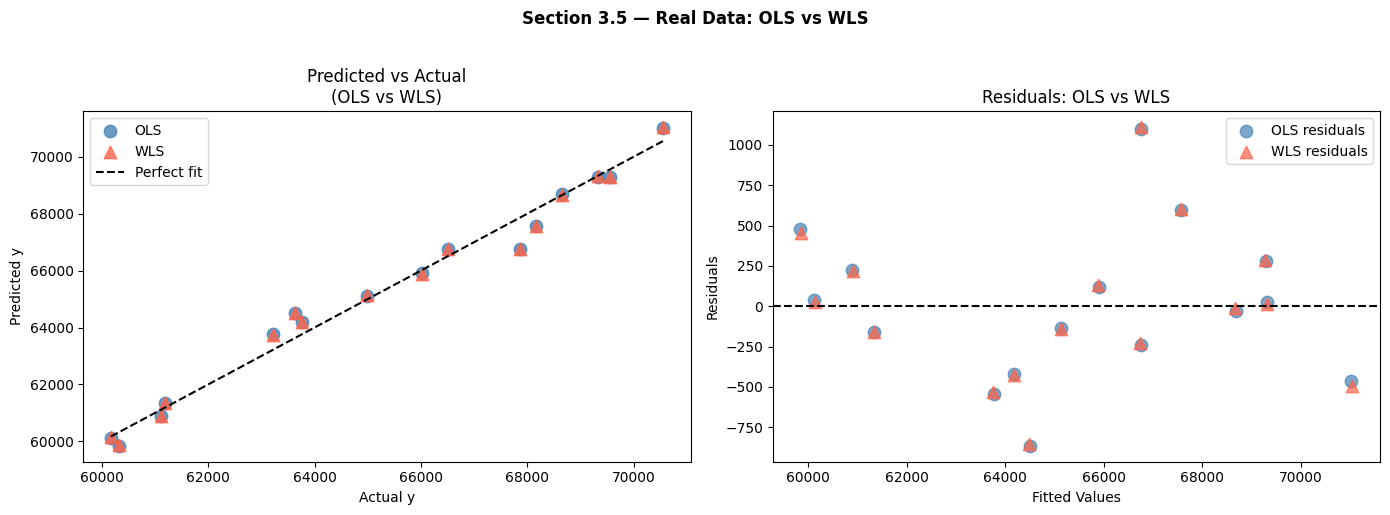

In [18]:
# ============================================================
# Section 3.5 — Final Plot: OLS vs WLS Predictions
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Plot 1: Predicted vs Actual ────────────────────────────
axes[0].scatter(y_real, y_hat_real,
                color='steelblue', alpha=0.8, s=80, label='OLS')
axes[0].scatter(y_real, y_hat_wls,
                color='tomato', alpha=0.8, s=80, marker='^', label='WLS')
axes[0].plot([y_real.min(), y_real.max()],
             [y_real.min(), y_real.max()],
             'k--', linewidth=1.5, label='Perfect fit')
axes[0].set_xlabel('Actual y')
axes[0].set_ylabel('Predicted y')
axes[0].set_title('Predicted vs Actual\n(OLS vs WLS)')
axes[0].legend()

# ── Plot 2: Residuals Comparison ──────────────────────────
axes[1].scatter(y_hat_real, resid_real,
                color='steelblue', alpha=0.7, s=80, label='OLS residuals')
axes[1].scatter(y_hat_wls, resid_wls,
                color='tomato', alpha=0.7, s=80, marker='^', label='WLS residuals')
axes[1].axhline(0, color='black', linestyle='--', linewidth=1.5)
axes[1].set_xlabel('Fitted Values')
axes[1].set_ylabel('Residuals')
axes[1].set_title('Residuals: OLS vs WLS')
axes[1].legend()

plt.suptitle('Section 3.5 — Real Data: OLS vs WLS',
             fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [19]:
# ============================================================
# BONUS — Fisher Information Matrix and CRLB
# ============================================================

import numpy as np
from numpy.linalg import inv
import matplotlib.pyplot as plt

# ── Fisher Information Matrix ──────────────────────────────
# I(beta) = -E[d²ell/dbeta dbeta^T]
# For Gaussian linear model:
# I(beta) = (1/sigma2) * X^T X
fisher_info = (1 / sigma2) * X.T @ X       # shape: (3, 3)

# ── CRLB ──────────────────────────────────────────────────
# Var(beta_hat) >= I(beta)^{-1} = sigma2 * (X^T X)^{-1}
crlb = inv(fisher_info)                     # = sigma2 * (X^TX)^{-1}

# ── OLS Covariance ─────────────────────────────────────────
# Cov(beta_hat_OLS) = sigma2 * (X^T X)^{-1}
ols_cov = sigma2 * inv(X.T @ X)

# ── Verify OLS achieves CRLB ──────────────────────────────
# Cov(OLS) - CRLB should be zero matrix (or very close)
diff = ols_cov - crlb

print("=" * 55)
print("BONUS — Fisher Information Matrix")
print("=" * 55)
print(f"\n  I(beta) = (1/sigma2) * X^T X:")
print(f"  {fisher_info.round(4)}")

print(f"\n  CRLB = I(beta)^{{-1}} = sigma2 * (X^TX)^{{-1}}:")
print(f"  {crlb.round(4)}")

print(f"\n  OLS Covariance = sigma2 * (X^TX)^{{-1}}:")
print(f"  {ols_cov.round(4)}")

print(f"\n  Cov(OLS) - CRLB:")
print(f"  {diff.round(10)}")

print(f"\n  OLS achieves CRLB: {np.allclose(ols_cov, crlb)}")
print(f"  => OLS is the EFFICIENT estimator ✓")

print(f"\n  Diagonal comparison (variances):")
print(f"  {'':12s} {'CRLB':>12} {'OLS Cov':>12} {'Match':>8}")
names = ['beta_0', 'beta_1', 'beta_2']
for j in range(3):
    match = np.isclose(crlb[j,j], ols_cov[j,j])
    print(f"  {names[j]:12s} {crlb[j,j]:>12.6f} {ols_cov[j,j]:>12.6f} {'✓' if match else '✗':>8}")

BONUS — Fisher Information Matrix

  I(beta) = (1/sigma2) * X^T X:
  [[100.     -11.5564   3.4022]
 [-11.5564  73.9295   2.3438]
 [  3.4022   2.3438  98.8899]]

  CRLB = I(beta)^{-1} = sigma2 * (X^TX)^{-1}:
  [[ 0.0102  0.0016 -0.0004]
 [ 0.0016  0.0138 -0.0004]
 [-0.0004 -0.0004  0.0101]]

  OLS Covariance = sigma2 * (X^TX)^{-1}:
  [[ 0.0102  0.0016 -0.0004]
 [ 0.0016  0.0138 -0.0004]
 [-0.0004 -0.0004  0.0101]]

  Cov(OLS) - CRLB (should be zero):
  [[0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]]

  OLS achieves CRLB: True
  => OLS is the EFFICIENT estimator ✓

  Diagonal comparison (variances):
                       CRLB      OLS Cov    Match
  beta_0           0.010199     0.010199        ✓
  beta_1           0.013790     0.013790        ✓
  beta_2           0.010135     0.010135        ✓


In [20]:
# ============================================================
# BONUS — Sufficient Statistics via Factorization Theorem
# ============================================================


T1 = X.T @ y_homo              # X^T y — shape: (3,)
T2 = y_homo @ y_homo           # y^T y — scalar


beta_from_T1 = inv(X.T @ X) @ T1
beta_direct  = OLS(X, y_homo)

sigma2_from_T = (1/n) * (T2 - beta_from_T1 @ T1)
sigma2_direct = ((y_homo - X @ beta_direct)**2).mean()

print("=" * 55)
print("BONUS — Sufficient Statistics")
print("=" * 55)

print(f"""
  Factorization Theorem:
  p(y|beta,sigma2) = h(y) * g(T(y), beta, sigma2)

  Expanding ||y - X@beta||^2:
  = y^Ty - 2*beta^T(X^Ty) + beta^T(X^TX)beta
  = T2   - 2*beta^T * T1  + beta^T(X^TX)beta

  => Likelihood depends on data ONLY through:
     T1(y) = X^T y    (sufficient for beta)
     T2(y) = y^T y    (sufficient for sigma2)
""")

print(f"  T1 = X^T y = {T1.round(4)}")
print(f"  T2 = y^T y = {T2:.4f}")

print(f"\n  Verification — OLS from T1 only:")
print(f"  beta from T1     : {beta_from_T1.round(6)}")
print(f"  beta from y      : {beta_direct.round(6)}")
print(f"  Match            : {np.allclose(beta_from_T1, beta_direct)} ✓")

print(f"\n  Verification — sigma2 from T1 and T2 only:")
print(f"  sigma2 from T1,T2: {sigma2_from_T:.6f}")
print(f"  sigma2 from y    : {sigma2_direct:.6f}")
print(f"  Match            : {np.isclose(sigma2_from_T, sigma2_direct)} ✓")

print(f"""
  Interpretation:
  - X^Ty compresses all n={n} observations into 3 numbers
  - These 3 numbers contain ALL information about beta
  - No other function of y can add information about beta
  - This is data compression with zero information loss
""")

BONUS — Sufficient Statistics

  Factorization Theorem:
  p(y|beta,sigma2) = h(y) * g(T(y), beta, sigma2)

  Expanding ||y - X@beta||^2:
  = y^Ty - 2*beta^T(X^Ty) + beta^T(X^TX)beta
  = T2   - 2*beta^T * T1  + beta^T(X^TX)beta

  => Likelihood depends on data ONLY through:
     T1(y) = X^T y    (sufficient for beta)
     T2(y) = y^T y    (sufficient for sigma2)

  T1 = X^T y = [186.4332  98.5303 -85.0521]
  T2 = y^T y = 750.4397

  Verification — OLS from T1 only:
  beta from T1     : [ 2.092793  1.69072  -0.972142]
  beta from y      : [ 2.092793  1.69072  -0.972142]
  Match            : True ✓

  Verification — sigma2 from T1 and T2 only:
  sigma2 from T1,T2: 1.110035
  sigma2 from y    : 1.110035
  Match            : True ✓

  Interpretation:
  - X^Ty compresses all n=100 observations into 3 numbers
  - These 3 numbers contain ALL information about beta
  - No other function of y can add information about beta
  - This is data compression with zero information loss



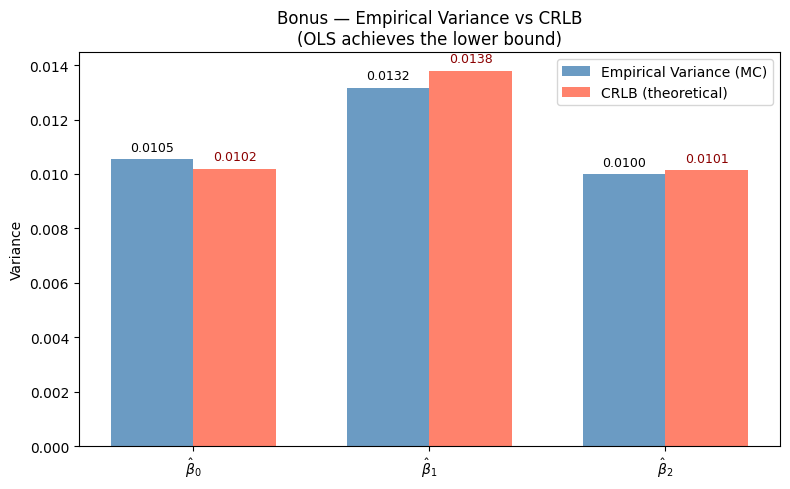

Empirical Variance ≈ CRLB for all coefficients
=> OLS is efficient: it achieves the Cramer-Rao Lower Bound ✓


In [21]:
# ============================================================
# BONUS — Visualize: Empirical Variance vs CRLB
# ============================================================


fig, ax = plt.subplots(figsize=(8, 5))

emp_var  = emp_std**2
crlb_var = np.diag(crlb)

x_pos  = np.arange(3)
width  = 0.35

bars1 = ax.bar(x_pos - width/2, emp_var,
               width, label='Empirical Variance (MC)',
               color='steelblue', alpha=0.8)
bars2 = ax.bar(x_pos + width/2, crlb_var,
               width, label='CRLB (theoretical)',
               color='tomato', alpha=0.8)

ax.set_xticks(x_pos)
ax.set_xticklabels([r'$\hat{\beta}_0$',
                    r'$\hat{\beta}_1$',
                    r'$\hat{\beta}_2$'])
ax.set_ylabel('Variance')
ax.set_title('Bonus — Empirical Variance vs CRLB\n'
             '(OLS achieves the lower bound)')
ax.legend()

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.0002,
            f'{bar.get_height():.4f}',
            ha='center', va='bottom', fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.0002,
            f'{bar.get_height():.4f}',
            ha='center', va='bottom', fontsize=9, color='darkred')

plt.tight_layout()
plt.show()

print("Empirical Variance ≈ CRLB for all coefficients")
print("=> OLS is efficient: it achieves the Cramer-Rao Lower Bound ✓")